# 03 — Entraînement multi-modèles & Tracking MLflow

## Objectif

Comparer plusieurs modèles de scoring crédit via validation croisée
et choisir le modèle retenu avant phase de tuning.

## Méthodologie

Les modèles ont été entraînés via scripts reproductibles :

- uv run python scripts/train_mlflow.py --cv 5
- uv run python scripts/train_mlflow.py --cv 5 --undersample

Les métriques suivies :

- roc_auc_mean
- pr_auc_mean
- business_cost_per_row
- best_threshold_mean

Le critère principal de sélection est business_cost_per_row
(minimisation du coût métier).

MLflow : uv run mlflow ui --host 127.0.0.1 --port 5001 --backend-store-uri sqlite:///mlflow/mlflow.db --default-artifact-root ./mlflow/artifacts

In [4]:
from pathlib import Path
import mlflow
from mlflow.tracking import MlflowClient

# ---- Détection robuste de la racine du projet (cherche dossier 'src') ----
cwd = Path().resolve()
root = cwd

while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise RuntimeError("Impossible de trouver la racine du projet (dossier 'src' introuvable).")

# ---- DB SQLite réelle ----
db_path = (root / "mlflow" / "mlflow.db").resolve()

if not db_path.exists():
    raise RuntimeError(f"Base MLflow introuvable : {db_path}")

TRACKING_URI = f"sqlite:///{db_path.as_posix()}"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiments disponibles:", [e.name for e in client.search_experiments()])

Tracking URI: sqlite:///G:/Mon Drive/OC/Projet_6/credexp/mlflow/mlflow.db
Experiments disponibles: ['credexp', 'Default']


In [5]:
EXP_NAME = "credexp"

exp = mlflow.get_experiment_by_name(EXP_NAME)

if exp is None:
    raise RuntimeError(
        f"Experiment '{EXP_NAME}' introuvable. "
        f"Disponibles: {[e.name for e in client.search_experiments()]}"
    )

print("Exp utilisée :", exp.name, "| id:", exp.experiment_id)

Exp utilisée : credexp | id: 1


## Construction du tableau comparatif

Nous extrayons uniquement les métriques pertinentes pour la comparaison
des modèles en validation croisée.

In [6]:
cols = [
    "tags.mlflow.runName",
    "params.model",
    "params.activation",
    "params.use_undersampling",
    "metrics.roc_auc_mean",
    "metrics.pr_auc_mean",
    "metrics.business_cost_per_row",
    "metrics.best_threshold_mean",
]

cols = [c for c in cols if c in runs.columns]

df = runs[cols].copy()

# On enlève les runs incomplets
if "metrics.business_cost_per_row" in df.columns:
    df = df.dropna(subset=["metrics.business_cost_per_row"])

df = df.sort_values("metrics.business_cost_per_row", ascending=True)

display(df.head(20))

,tags.mlflow.runName,params.model,params.activation,params.use_undersampling,metrics.roc_auc_mean,metrics.pr_auc_mean,metrics.business_cost_per_row,metrics.best_threshold_mean
2,lgbm,lgbm,,True,0.782813,0.269348,30397.0,0.530
8,lgbm,lgbm,,False,0.781373,0.273479,30452.2,0.368
11,lr,lr,,False,0.773165,0.252933,31115.6,0.514
9,mlp_logistic,mlp,logistic,False,0.773247,0.254421,31246.8,0.530
5,lr,lr,,True,0.769696,0.243935,31335.6,0.532
3,mlp_logistic,mlp,logistic,True,0.770130,0.246887,31488.4,0.518
10,mlp_relu,mlp,relu,False,0.765101,0.244804,31964.6,0.498
4,mlp_relu,mlp,relu,True,0.757023,0.229641,32690.2,0.530
7,dummy_most_frequent,dummy,most_frequent,True,0.500000,0.080730,49650.0,0.010
13,dummy_most_frequent,dummy,most_frequent,False,0.500000,0.080730,49650.0,0.010


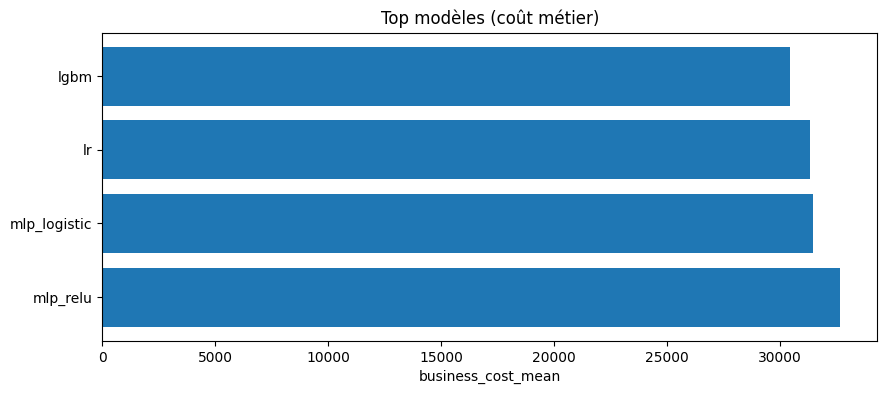

In [7]:
import matplotlib.pyplot as plt

topn = min(8, len(df))
tmp = df.head(topn)

plt.figure(figsize=(10, 4))
plt.barh(tmp["tags.mlflow.runName"], tmp["metrics.business_cost_per_row"])
plt.gca().invert_yaxis()
plt.xlabel("business_cost_per_row")
plt.title("Top modèles (coût métier)")
plt.show()

## Interprétation des résultats

- Les modèles Dummy servent de contrôle minimal.
- La régression logistique fournit une baseline interprétable.
- Le MLP permet de tester une approche réseau de neurones.
- LightGBM obtient généralement les meilleures performances sur données tabulaires.

Le critère principal de sélection est la minimisation du coût métier
(business_cost_per_row).

In [8]:
best = df.iloc[0]

print("Meilleur run :")
display(best)

Meilleur run :


tags.mlflow.runName                lgbm
params.model                       lgbm
params.activation                      
params.use_undersampling           True
metrics.roc_auc_mean           0.782813
metrics.pr_auc_mean            0.269348
metrics.business_cost_per_row      30397.0
metrics.best_threshold_mean        0.53
Name: 2, dtype: object

## Synthèse & choix du modèle (avant tuning)

D’après la validation croisée :

- Les baselines Dummy sont largement dépassées.
- La Logistic Regression constitue une baseline robuste.
- Les modèles boosting (LightGBM) offrent le meilleur compromis performance / stabilité.
- Le MLP reste en retrait sur ce jeu tabulaire.

Modèle retenu avant tuning :
➡️ LightGBM avec undersampling

Justification :
- Minimisation du coût métier
- ROC-AUC et PR-AUC compétitifs
- Stabilité sur les folds